# Instrumental Variable & Regression Discontinuity 
## Week 4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read first data set
df1 = pd.read_csv("homework_4.1.csv")
df1.head()

,Z,W,X,Y
0,0,-0.155644,-0.496971,0.282484
1,1,0.529539,2.284240,4.740596
2,1,0.910514,0.872232,3.449569
3,1,-0.705476,2.157260,3.002531
4,0,-0.590874,-0.386730,-1.848796


In [3]:
df1_z1 = df1[df1["Z"] == 1]
df1_z1

,Z,W,X,Y
1,1,0.529539,2.284240,4.740596
2,1,0.910514,0.872232,3.449569
3,1,-0.705476,2.157260,3.002531
5,1,0.533635,0.981649,1.866566
9,1,-1.548130,0.126844,-0.379818
...,...,...,...,...
4989,1,-0.500849,-0.597665,-1.424123
4990,1,1.882335,1.442127,2.533808
4991,1,0.199374,2.294895,3.455866
4992,1,1.934735,-0.350092,2.379009


In [4]:
df1_z0 = df1[df1["Z"] ==0]
df1_z0

,Z,W,X,Y
0,0,-0.155644,-0.496971,0.282484
4,0,-0.590874,-0.386730,-1.848796
6,0,1.293241,-0.041748,2.427692
7,0,0.243445,-0.113452,-0.177196
8,0,-0.714465,-0.129564,1.673641
...,...,...,...,...
4995,0,-0.976289,0.482060,-0.830112
4996,0,0.677586,-0.580264,1.106948
4997,0,-0.829560,0.895967,-0.612659
4998,0,-1.126846,-0.178558,-2.882220


In [8]:
df1_z1_avg_y = df1_z1["Y"].mean()
df1_z1_avg_y

np.float64(1.5334744841544254)

In [9]:
df1_z0_avg_y = df1_z0["Y"].mean()
df1_z0_avg_y

np.float64(-0.057370742020927984)

In [10]:
df1_z1_avg_x = df1_z1["X"].mean()
df1_z1_avg_x

np.float64(1.0091964255717258)

In [12]:
df1_z0_avg_x = df1_z0["X"].mean()
df1_z0_avg_x

np.float64(-0.009362563574908741)

In [14]:
(df1_z1_avg_y - df1_z0_avg_y)/(df1_z1_avg_x - df1_z0_avg_x)

np.float64(1.5618587073765746)

In [16]:
# or we can write code like this
mean_by_z = df1.groupby("Z")[["X", "Y"]].mean()

delta_y = mean_by_z.loc[1, "Y"] - mean_by_z.loc[0, "Y"]
delta_x = mean_by_z.loc[1, "X"] - mean_by_z.loc[0, "X"]

effect = delta_y / delta_x
effect

np.float64(1.5618587073765746)

In [17]:
df1["W"].describe()

count    5000.000000
mean       -0.009934
std         0.997779
min        -3.303406
25%        -0.697551
50%        -0.032234
75%         0.647618
max         4.783257
Name: W, dtype: float64

<Axes: >

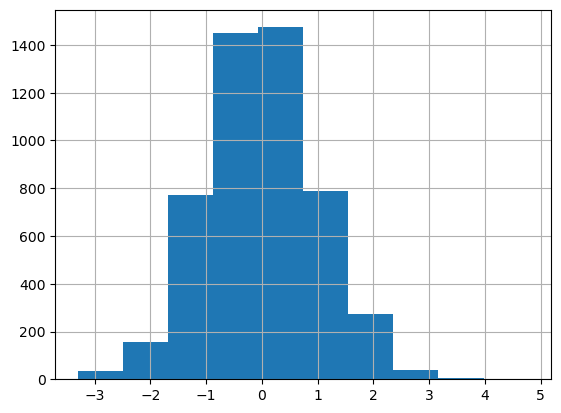

In [18]:
df1['W'].hist()

In [21]:
# create narrow ranges (bins) of w
bins = np.arange(df1["W"].min(), df1["W"].max() + 0.5, 0.5)

df1["W_bin"] = pd.cut(df1["W"] , bins=bins)
df1[["W", "W_bin"]].head(10)

,W,W_bin
0,-0.155644,"(-0.303, 0.197]"
1,0.529539,"(0.197, 0.697]"
2,0.910514,"(0.697, 1.197]"
3,-0.705476,"(-0.803, -0.303]"
4,-0.590874,"(-0.803, -0.303]"
5,0.533635,"(0.197, 0.697]"
6,1.293241,"(1.197, 1.697]"
7,0.243445,"(0.197, 0.697]"
8,-0.714465,"(-0.803, -0.303]"
9,-1.548130,"(-1.803, -1.303]"


In [22]:
# Calculate average X and Y for each W range and Z group

bin_means = (
    df1.groupby(["W_bin", "Z"], observed=True)[["X", "Y"]]
    .mean()
)
bin_means.head(10)

X         Y
W_bin            Z                    
(-3.303, -2.803] 0  0.242002 -2.714444
                 1  1.647544 -0.907394
(-2.803, -2.303] 0 -0.254705 -3.174104
                 1  0.630028 -1.596453
(-2.303, -1.803] 0 -0.049017 -2.269320
                 1  0.750051 -1.061829
(-1.803, -1.303] 0 -0.030461 -1.552393
                 1  1.073524  0.076027
(-1.303, -0.803] 0  0.058038 -0.890558
                 1  1.018010  0.438380

In [23]:
# Put Z=0 and Z=1 side by side 
wide_means = bin_means.unstack("Z")

wide_means.head()

X                   Y          
Z                        0         1         0         1
W_bin                                                   
(-3.303, -2.803]  0.242002  1.647544 -2.714444 -0.907394
(-2.803, -2.303] -0.254705  0.630028 -3.174104 -1.596453
(-2.303, -1.803] -0.049017  0.750051 -2.269320 -1.061829
(-1.803, -1.303] -0.030461  1.073524 -1.552393  0.076027
(-1.303, -0.803]  0.058038  1.018010 -0.890558  0.438380

In [24]:
# Calculate the effect within each W bin

wide_means["delta_X"] = wide_means["X"][1] - wide_means["X"][0]
wide_means["delta_Y"] = wide_means["Y"][1] - wide_means["Y"][0]

wide_means["effect"] = wide_means["delta_Y"] / wide_means["delta_X"]

wide_means.head()

X                   Y             delta_X   delta_Y  \
Z                        0         1         0         1                       
W_bin                                                                          
(-3.303, -2.803]  0.242002  1.647544 -2.714444 -0.907394  1.405543  1.807050   
(-2.803, -2.303] -0.254705  0.630028 -3.174104 -1.596453  0.884734  1.577651   
(-2.303, -1.803] -0.049017  0.750051 -2.269320 -1.061829  0.799068  1.207491   
(-1.803, -1.303] -0.030461  1.073524 -1.552393  0.076027  1.103985  1.628421   
(-1.303, -0.803]  0.058038  1.018010 -0.890558  0.438380  0.959972  1.328938   

                    effect  
Z                           
W_bin                       
(-3.303, -2.803]  1.285660  
(-2.803, -2.303]  1.783194  
(-2.303, -1.803]  1.511123  
(-1.803, -1.303]  1.475039  
(-1.303, -0.803]  1.384350

In [25]:
wide_means["effect"].mean()

np.float64(1.1252715412424652)

In [26]:
# Read the two datasets
df_a = pd.read_csv("homework_4.2.a.csv")
df_b = pd.read_csv("homework_4.2.b.csv")

display(df_a.head())
display(df_b.head())

,X,Y
0,81.822339,1
1,92.487870,0
2,85.372460,0
3,78.828025,0
4,75.807080,1


,X2,Y2
0,76.643034,1
1,87.743397,1
2,81.639469,1
3,73.740485,0
4,90.480268,1


In [28]:
df_a.shape


(100000, 2)

In [29]:
df_b.shape

(100000, 2)

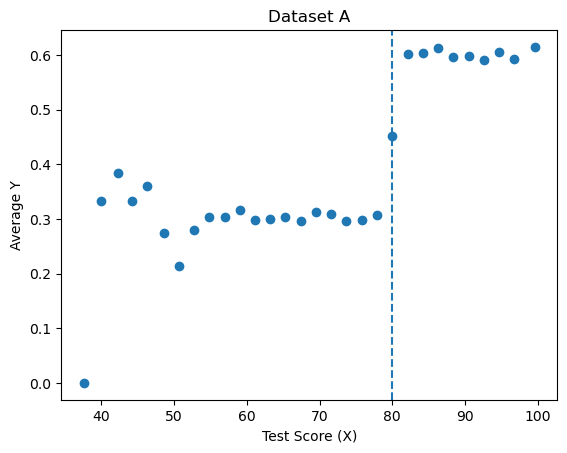

In [30]:
# Dataset A: average outcome by score bins

df_a["X_bin"] = pd.cut(df_a["X"], bins=30)

plot_a = df_a.groupby("X_bin", observed=True).agg(
    X_mean=("X", "mean"),
    Y_mean=("Y", "mean")
)

plt.scatter(plot_a["X_mean"], plot_a["Y_mean"])
plt.axvline(x=80, linestyle="--")
plt.xlabel("Test Score (X)")
plt.ylabel("Average Y")
plt.title("Dataset A")
plt.show()

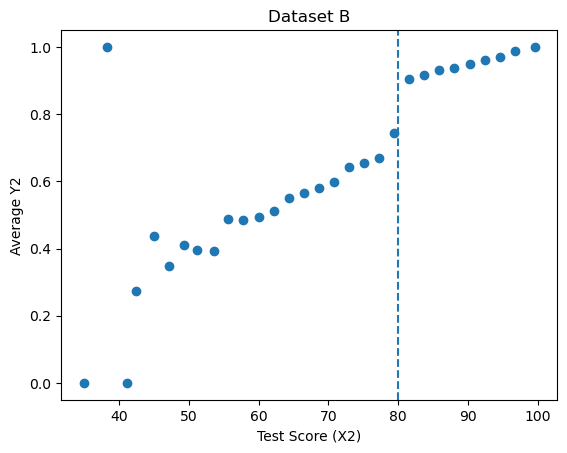

In [31]:
# Dataset B: average outcome by score bins

df_b["X_bin"] = pd.cut(df_b["X2"], bins=30)

plot_b = df_b.groupby("X_bin", observed=True).agg(
    X_mean=("X2", "mean"),
    Y_mean=("Y2", "mean")
)

plt.scatter(plot_b["X_mean"], plot_b["Y_mean"])
plt.axvline(x=80, linestyle="--")
plt.xlabel("Test Score (X2)")
plt.ylabel("Average Y2")
plt.title("Dataset B")
plt.show()

# Week 4 Summary: Instrumental Variables & Regression Discontinuity

This notebook explored two important methods for causal inference:

1. **Instrumental Variables (IV)**
2. **Regression Discontinuity (RD)**

The main goal is to estimate causal effects when a simple comparison or regression may not provide a reliable causal estimate.

---

# Part 1: Instrumental Variables (IV)

## The Problem

Suppose we want to estimate the causal effect of a treatment **X** on an outcome **Y**.

However, a confounder **W** may affect both X and Y.

- **X** = Treatment
- **Y** = Outcome
- **W** = Confounder
- **Z** = Instrument

Because W affects both X and Y, simply comparing different values of X may not identify the true causal effect.

An **Instrumental Variable (Z)** can help isolate useful variation in X.

Conceptually:

**Z → X → Y**

The instrument should affect X, while its effect on Y should operate through X.

---

## Wald Estimator

When the instrument Z is binary (Z = 0 or Z = 1), we can estimate the effect using:

**IV Effect = ΔY / ΔX**

where:

**ΔY = E[Y | Z=1] − E[Y | Z=0]**

and:

**ΔX = E[X | Z=1] − E[X | Z=0]**

Therefore:

**IV Effect = (Average Y when Z=1 − Average Y when Z=0) / (Average X when Z=1 − Average X when Z=0)**

In our dataset:

**IV Effect ≈ 1.56**

### Interpretation

The numerator asks:

> How much does Y change when Z changes from 0 to 1?

The denominator asks:

> How much does X change when Z changes from 0 to 1?

The ratio tells us how much Y changes relative to the change in X induced by the instrument.

---

## Important Python Idea: groupby()

Instead of manually separating Z=0 and Z=1, we can calculate the group averages using:

`df.groupby("Z")[["X", "Y"]].mean()`

Then we calculate:

**ΔY = Y(Z=1) − Y(Z=0)**

**ΔX = X(Z=1) − X(Z=0)**

and finally:

**Effect = ΔY / ΔX**

This gives the same result as the longer manual approach.

---

# Part 2: Accounting for the Confounder W

Another approach was to compare observations within **narrow ranges of W**.

Because W is continuous, observations will usually not have exactly the same W value.

Therefore, we divided W into small bins.

For example:

- (-0.8, -0.3]
- (-0.3, 0.2]
- (0.2, 0.7]
- (0.7, 1.2]

Within each W bin, we separately compared observations with:

- Z = 0
- Z = 1

For each bin, we calculated:

**ΔY(w) = Average Y(Z=1) − Average Y(Z=0)**

**ΔX(w) = Average X(Z=1) − Average X(Z=0)**

Then:

**Effect(w) = ΔY(w) / ΔX(w)**

Finally, the effects across the W ranges were averaged.

### Main Idea

Instead of comparing everyone at once, we compare observations with approximately similar values of W.

This allows us to examine the IV effect while accounting for the confounder.

---

# Part 3: Regression Discontinuity (RD)

Regression Discontinuity is useful when treatment assignment changes at a known **cutoff**.

In our exercise:

**Cutoff = 80**

The basic idea is to compare observations around the cutoff.

If treatment changes at the cutoff and we observe a sudden change in Y, that discontinuity can provide information about the causal effect of the treatment.

---

# Jump vs. Slope

This is one of the most important concepts from this exercise.

## Jump / Discontinuity

A **jump** is a sudden change in Y exactly at the cutoff.

For example:

Before cutoff:

**Y ≈ 0.30**

Immediately after cutoff:

**Y ≈ 0.60**

This sudden difference is the **discontinuity**.

In RD, the jump at the cutoff is the key quantity used to identify the treatment effect.

---

## Slope

The **slope** describes how Y gradually changes as X changes.

### Positive slope

If:

**X increases → Y increases**

then the slope is positive.

### Negative slope

If:

**X increases → Y decreases**

then the slope is negative.

### Zero slope

If X changes but Y stays approximately constant, then:

**Slope ≈ 0**

---

# Dataset A

Dataset A showed an approximately flat relationship before and after the cutoff.

Before the cutoff:

**Slope ≈ 0**

After the cutoff:

**Slope ≈ 0**

However, there was a clear **jump at X = 80**.

Therefore, Dataset A mainly demonstrates:

**Jump at cutoff + approximately zero slope**

---

# Dataset B

Dataset B showed a clear relationship between X and Y.

Before the cutoff:

**X increases → Y increases**

Therefore:

**Slope before cutoff > 0**

At X = 80, there was also a clear jump in Y.

After the cutoff, Y continued increasing, but at a slower rate.

Therefore:

**Slope after cutoff < Slope before cutoff**

Dataset B therefore demonstrates:

**Positive slope + Jump at cutoff + Different slopes before and after cutoff**

---

# Important: Jump and Slope Are Different

A **jump** describes a sudden change exactly at the cutoff.

A **slope** describes the gradual change in Y as X changes.

Therefore:

**A large jump does NOT necessarily mean a large slope.**

Always analyze these two features separately.

---

# Key Takeaways

## Instrumental Variables

- IV helps estimate causal effects when X and Y are confounded.
- Z is the instrument.
- X is the treatment.
- Y is the outcome.
- W is the confounder.
- With a binary instrument:

**IV Effect = ΔY / ΔX**

The instrument provides variation in X that can help identify the causal effect of X on Y.

---

## Regression Discontinuity

- RD uses a known cutoff.
- Treatment changes around that cutoff.
- We examine what happens to Y near the cutoff.
- A sudden change in Y is called a **jump or discontinuity**.
- The slope describes the gradual relationship between X and Y.
- Jump and slope should be interpreted separately.

---

# Final Mental Models

## Instrumental Variables

Think:

**"Use Z to isolate useful variation in X and estimate the causal effect of X on Y."**

**Z → X → Y**

## Regression Discontinuity

Think:

**"Look for a sudden change in Y when X crosses a known cutoff."**

**Before cutoff | Cutoff | After cutoff**

---

# Final Lesson

The main lesson from Week 4 is that causal inference often requires more than observing a correlation between X and Y.

**Instrumental Variables** use an external source of variation (Z) to help identify the causal effect of X on Y.

**Regression Discontinuity** uses a treatment cutoff and examines the discontinuity in Y around that threshold.

Both methods provide strategies for moving from simple associations toward more credible causal estimates.